# 11 — Embeddings v3: angular sector encoding

**v2 finding:** lens space is non-smooth under Syracuse iteration. The analogy
direction `Phi(b) - Phi(a)` flips sign at k=1.

**v2 diagnosis:** sector is one-hot encoded and decrements by 1 mod 12 per
Syracuse step. Each step flips one-hot indices to *orthogonal* indices, dominating
the vector arithmetic with discrete jumps.

**v3 fix to test:** replace sector's one-hot encoding with `(cos(2*pi*s/12), sin(2*pi*s/12))`.
A -1 mod 12 sector step is then a -30 deg rotation in a 2D sector subspace —
smooth, not a discontinuous index hop. Everything else stays one-hot.

**Prediction:** `Phi_angular`-based drift curves should *not* exhibit the k=1 flip.
If confirmed, lens space becomes smooth under iteration once we encode cyclic
lenses cyclically.

**Falsifying outcomes:**
- `Phi_angular` drift looks identical to `Phi` -> sector wasn't the (sole) cause; alpha_prefix and drop_class are also discontinuous
- `Phi_angular` drift improves but only modestly -> sector is one factor among many
- `Phi_angular` drift is dramatically smoother -> diagnosis confirmed; cyclic encoding is the right move for any lens with a known group structure


In [1]:
import sys
sys.path.insert(0, '..')
import random
import numpy as np
import matplotlib.pyplot as plt

from collatz.embeddings import Concept, Phi, Phi_angular, T_syracuse
from collatz.embeddings.distance import cosine
from collatz.embeddings.iteration import _syr_step


## 1. Generate quads — same setup as notebook 10


In [2]:
random.seed(7)  # same seed as nb 10 for direct comparison
N_QUADS = 60

def random_triple(lo, hi):
    return tuple(random.randrange(lo, hi) | 1 for _ in range(3))

def shift(c: Concept) -> Concept:
    return Concept(c.name + "*", tuple(_syr_step(x) for x in c.vec))

quads = []
for i in range(N_QUADS):
    scale = random.choice([10, 50, 200, 1000, 5000])
    a = Concept(f"a{i}", random_triple(2, scale))
    c = Concept(f"c{i}", random_triple(2, scale))
    quads.append((a, shift(a), c, shift(c)))

print(f"{N_QUADS} quads (same seed as nb 10).")
print(f"Phi shape:         {Phi(quads[0][0]).shape}")
print(f"Phi_angular shape: {Phi_angular(quads[0][0]).shape}")


60 quads (same seed as nb 10).
Phi shape:         (219,)
Phi_angular shape: (189,)


## 2. Drift curves under both encodings


In [3]:
def iterate(c: Concept, k: int) -> Concept:
    for _ in range(k):
        c = T_syracuse(c)
    return c

K = 8
drift_onehot = np.zeros((N_QUADS, K + 1))
drift_angular = np.zeros((N_QUADS, K + 1))

for q_idx, (a, b, c, d) in enumerate(quads):
    base_diff_o = Phi(b) - Phi(a)
    base_diff_a = Phi_angular(b) - Phi_angular(a)
    for k in range(K + 1):
        ak = iterate(a, k)
        bk = iterate(b, k)
        diff_o = Phi(bk) - Phi(ak)
        diff_a = Phi_angular(bk) - Phi_angular(ak)
        drift_onehot[q_idx, k] = cosine(diff_o, base_diff_o)
        drift_angular[q_idx, k] = cosine(diff_a, base_diff_a)

print(f"{'k':>3} {'one-hot mean':>14} {'angular mean':>14} {'difference':>12}")
print("-" * 50)
for k in range(K + 1):
    om = drift_onehot[:, k].mean()
    am = drift_angular[:, k].mean()
    print(f"{k:>3} {om:>14.3f} {am:>14.3f} {am - om:>+12.3f}")


  k   one-hot mean   angular mean   difference


--------------------------------------------------
  0          1.000          1.000       +0.000
  1         -0.267         -0.224       +0.043
  2         -0.087         -0.089       -0.002
  3         -0.062         -0.057       +0.005
  4          0.074          0.074       +0.000
  5         -0.128         -0.151       -0.023
  6          0.043          0.038       -0.005
  7          0.014          0.012       -0.003
  8          0.079          0.076       -0.003


## 3. Plot — one-hot vs angular


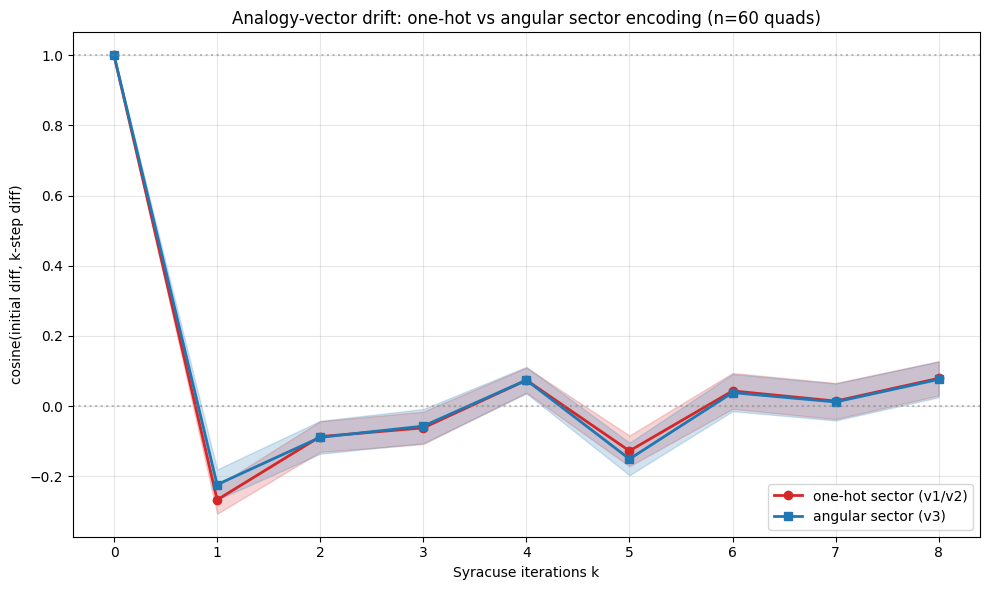

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ks = np.arange(K + 1)

# one-hot
om = drift_onehot.mean(axis=0)
ose = drift_onehot.std(axis=0) / np.sqrt(N_QUADS)
ax.plot(ks, om, marker="o", color="tab:red", label="one-hot sector (v1/v2)", linewidth=2)
ax.fill_between(ks, om - ose, om + ose, color="tab:red", alpha=0.2)

# angular
am = drift_angular.mean(axis=0)
ase = drift_angular.std(axis=0) / np.sqrt(N_QUADS)
ax.plot(ks, am, marker="s", color="tab:blue", label="angular sector (v3)", linewidth=2)
ax.fill_between(ks, am - ase, am + ase, color="tab:blue", alpha=0.2)

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.axhline(1, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Syracuse iterations k")
ax.set_ylabel("cosine(initial diff, k-step diff)")
ax.set_title(f"Analogy-vector drift: one-hot vs angular sector encoding (n={N_QUADS} quads)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Targeted check — does the k=1 sign flip disappear?


In [5]:
flips_onehot = (drift_onehot[:, 1] < 0).sum()
flips_angular = (drift_angular[:, 1] < 0).sum()
print(f"Quads with negative cosine at k=1:")
print(f"  one-hot:  {flips_onehot:>3}/{N_QUADS}  (mean = {drift_onehot[:, 1].mean():+.3f})")
print(f"  angular:  {flips_angular:>3}/{N_QUADS}  (mean = {drift_angular[:, 1].mean():+.3f})")
print()
print(f"Mean drift over k=1..8:")
print(f"  one-hot mean: {drift_onehot[:, 1:].mean():+.3f}")
print(f"  angular mean: {drift_angular[:, 1:].mean():+.3f}")


Quads with negative cosine at k=1:
  one-hot:   47/60  (mean = -0.267)
  angular:   45/60  (mean = -0.224)

Mean drift over k=1..8:
  one-hot mean: -0.042
  angular mean: -0.040


## 5. Verdict template

Read off the comparison:

- **`angular >> one-hot` at all k > 0** -> diagnosis confirmed; cyclic encoding fixes
  the discontinuity for sector. Next: apply the same treatment to other discrete lenses
  with known group structure (mod3 has a finite-state attractor; alpha_prefix doesn't have
  obvious cyclic structure but might benefit from a different smooth encoding).
- **`angular >~ one-hot`, modest improvement** -> sector is one factor among many.
  alpha_prefix and drop_class one-hots are also flipping. Need to address all discrete
  lenses, or move to trajectory-space embedding (spec's Approach B).
- **`angular ~ one-hot`** -> sector wasn't the cause. The discontinuity is elsewhere
  (likely the real-valued `force` decaying ~1.42 bits per Syracuse step changes the
  vector magnitude faster than we expected). Approach B becomes the priority.
